Name : Dhawale Sayali Vilas</br>
Experiment No.3</br>
IPCV








In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from  google.colab import drive
upload = files.upload()

Saving img.jpg to img.jpg


In [ ]:
img = cv2.imread('img.jpg', cv2.IMREAD_GRAYSCALE)

In [ ]:
img

array([[201, 202, 204, ..., 149, 150, 152],
       [202, 202, 202, ..., 144, 146, 148],
       [203, 202, 202, ..., 144, 146, 149],
       ...,
       [ 28,  27,  27, ..., 174, 176, 177],
       [ 26,  23,  19, ..., 174, 173, 177],
       [ 27,  24,  20, ..., 174, 173, 177]], dtype=uint8)

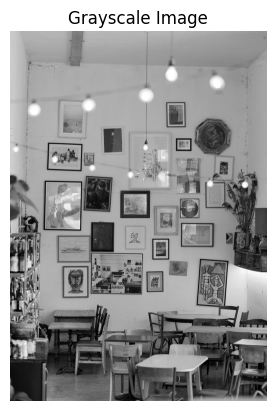

In [ ]:
plt.imshow(img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

In [ ]:
height, width = img.shape
total_pixels = height * width

In [ ]:
hist = np.zeros(256, dtype=int)

In [ ]:
for row in img:
    for pixel_value in row:
        hist[pixel_value] += 1

In [ ]:
hist, _ = np.histogram(img.flatten(), 256, [0, 256])


In [ ]:
hist_normalized = hist / total_pixels

In [ ]:
hist_normalized

array([0.00031379, 0.00088944, 0.00129371, 0.00138019, 0.00145625,
       0.00149488, 0.00147985, 0.00147662, 0.0015153 , 0.0015327 ,
       0.00164777, 0.00180725, 0.00193439, 0.00208948, 0.00223746,
       0.00237209, 0.00251197, 0.00266374, 0.00276762, 0.0028243 ,
       0.00280823, 0.00281009, 0.00274402, 0.00270935, 0.00268515,
       0.00266443, 0.00269195, 0.00273834, 0.00277438, 0.00278106,
       0.00282395, 0.0028162 , 0.00277761, 0.00276766, 0.00274574,
       0.00274669, 0.00274647, 0.00279295, 0.00280535, 0.00284665,
       0.00286935, 0.00290049, 0.0028945 , 0.00288175, 0.00288382,
       0.00286315, 0.00288739, 0.00287955, 0.00292159, 0.00291793,
       0.00293528, 0.00295833, 0.00295845, 0.00296423, 0.00293503,
       0.00292951, 0.00286999, 0.00284631, 0.00280487, 0.00278416,
       0.00278071, 0.00277705, 0.00278308, 0.00281327, 0.00283998,
       0.00283339, 0.00285647, 0.00287973, 0.00285414, 0.0028501 ,
       0.00282736, 0.00277141, 0.00270724, 0.0026749 , 0.00260

In [ ]:
cdf = np.cumsum(hist_normalized)

In [ ]:
L = 256

In [ ]:
new_values = np.round(255 * cdf).astype('uint8')

In [ ]:
for i in range(256):
        new_values[i] = int(round((L - 1) * cdf[i]))

In [ ]:
enhanced_img = new_values[img]


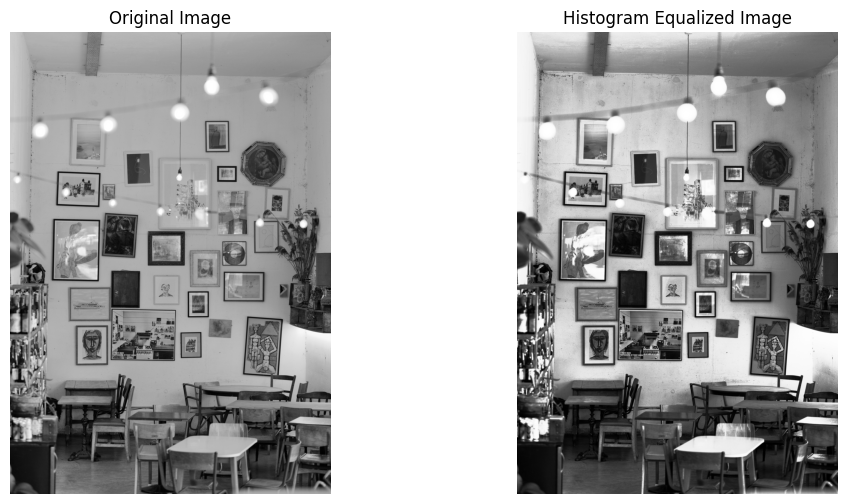

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img, cmap='gray')
plt.title('Histogram Equalized Image')
plt.axis('off')

plt.show()

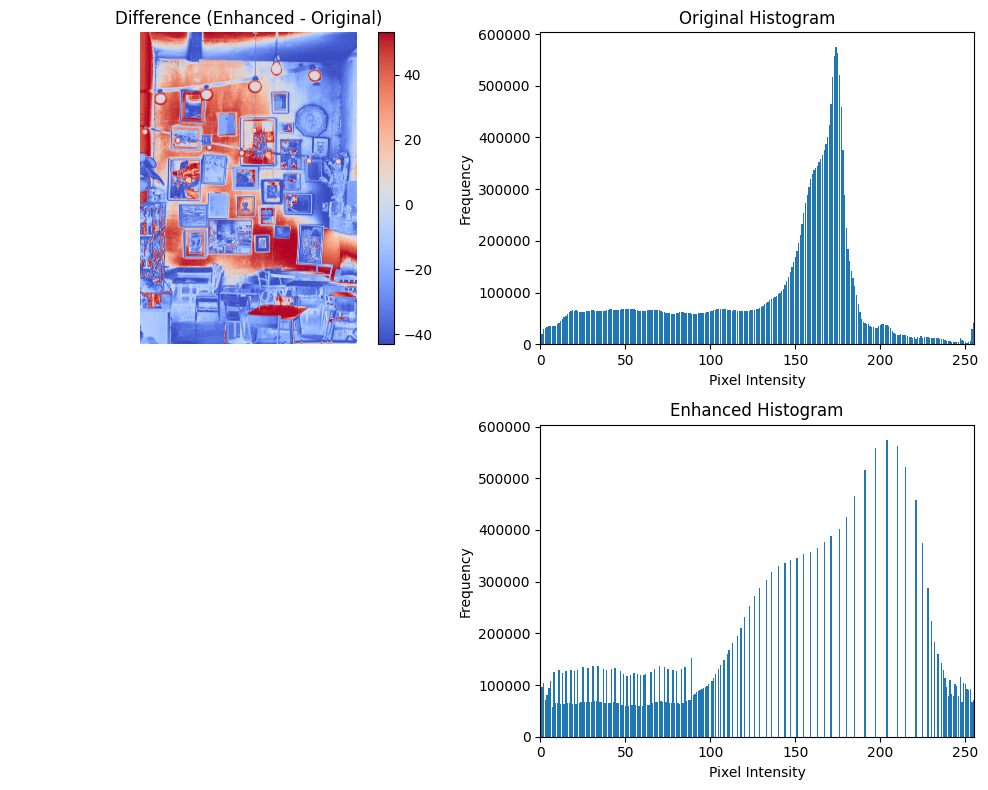

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # Create a new figure with a 2x2 grid of subplots

axes[0, 1].bar(range(256), hist)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim([0, 255])

# Calculate and plot enhanced histogram
enhanced_hist, _ = np.histogram(enhanced_img.flatten(), 256, [0, 256])
axes[1, 1].bar(range(256), enhanced_hist)
axes[1, 1].set_title('Enhanced Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim([0, 255])

# Calculate and plot difference image on axes[0, 0]
diff = enhanced_img.astype(int) - img.astype(int)
im_diff = axes[0, 0].imshow(diff, cmap='coolwarm')
axes[0, 0].set_title('Difference (Enhanced - Original)')
axes[0, 0].axis('off')
fig.colorbar(im_diff, ax=axes[0, 0]) # Attach colorbar to the figure, specifying the axis

# Clear axes[1,0] if not needed
axes[1, 0].axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

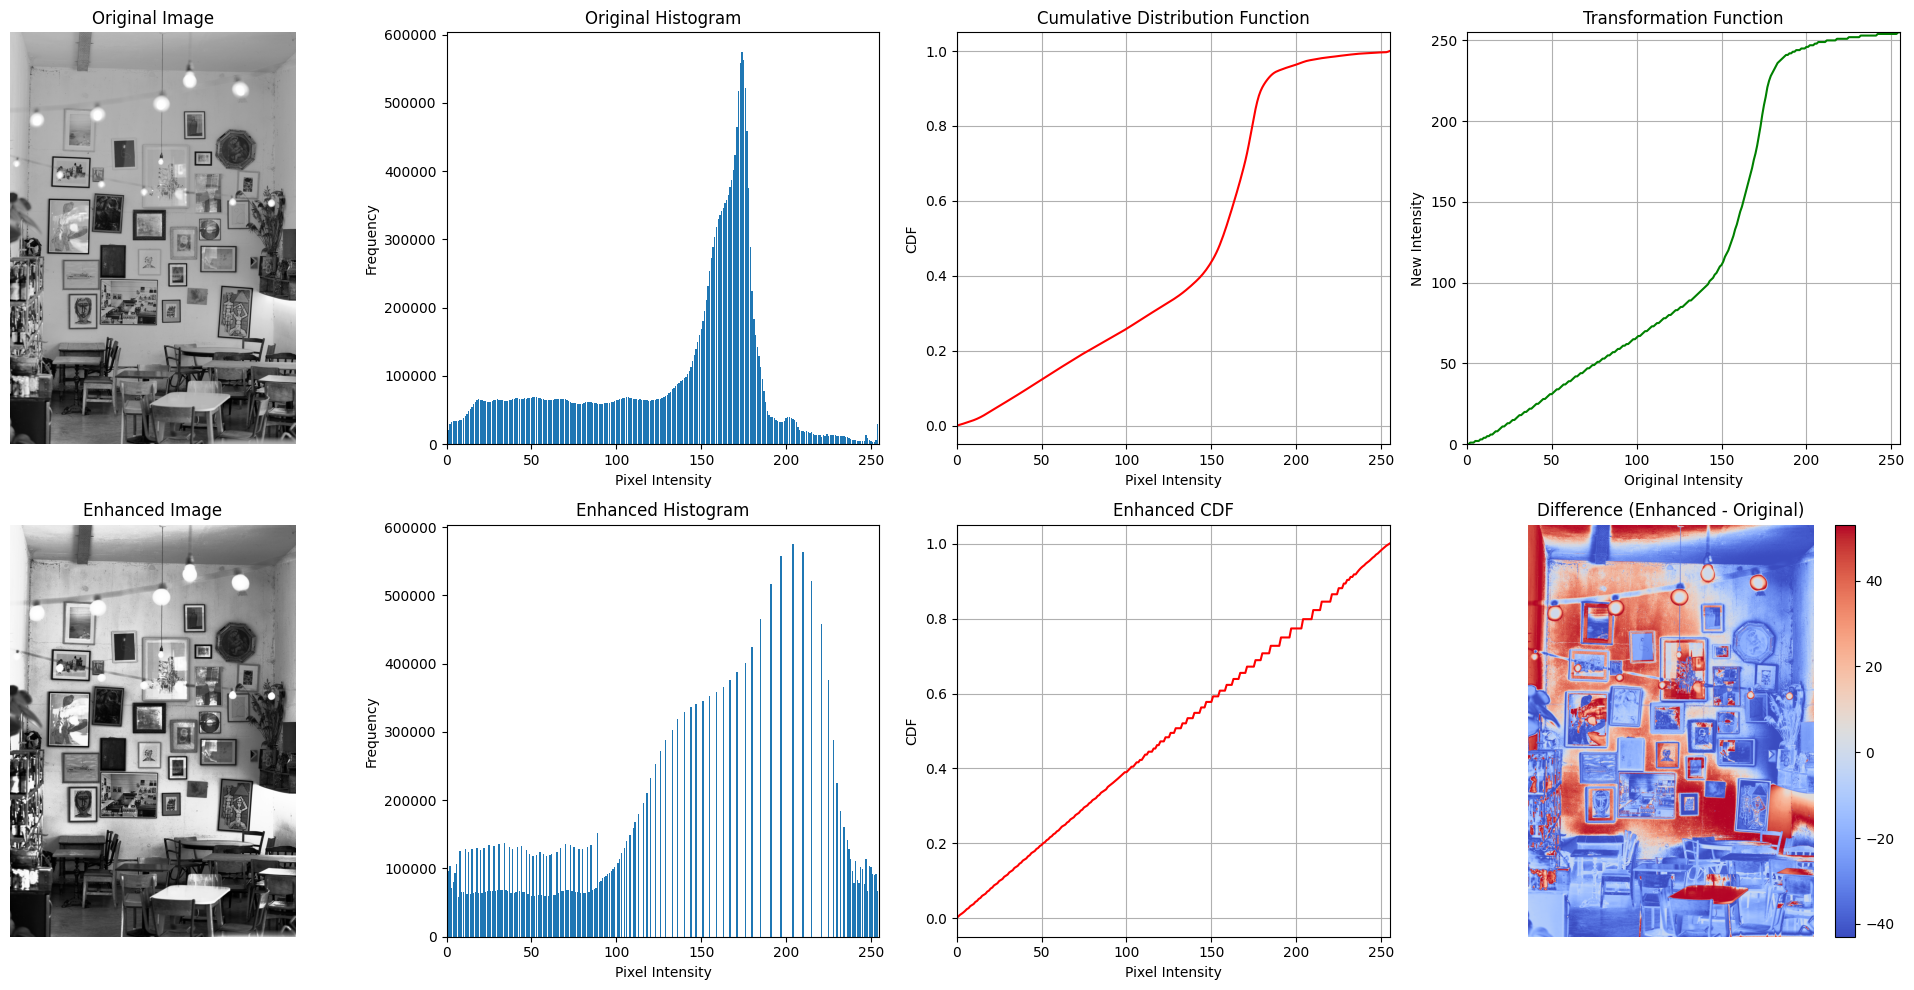

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) # Create a new figure with a 2x4 grid of subplots

# Original Image
axes[0, 0].imshow(img, cmap='gray') # Use img instead of original
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Original Histogram
axes[0, 1].bar(range(256), hist)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim([0, 255])

# Original CDF
axes[0, 2].plot(range(256), cdf, 'r-')
axes[0, 2].set_title('Cumulative Distribution Function')
axes[0, 2].set_xlabel('Pixel Intensity')
axes[0, 2].set_ylabel('CDF')
axes[0, 2].set_xlim([0, 255])
axes[0, 2].grid(True)

# Transformation Function
axes[0, 3].plot(range(256), new_values, 'g-')
axes[0, 3].set_title('Transformation Function')
axes[0, 3].set_xlabel('Original Intensity')
axes[0, 3].set_ylabel('New Intensity')
axes[0, 3].set_xlim([0, 255])
axes[0, 3].set_ylim([0, 255])
axes[0, 3].grid(True)

# Enhanced Image
axes[1, 0].imshow(enhanced_img, cmap='gray') # Use enhanced_img instead of enhanced
axes[1, 0].set_title('Enhanced Image')
axes[1, 0].axis('off')

# Enhanced Histogram
enhanced_hist, _ = np.histogram(enhanced_img.flatten(), 256, [0, 256]) # Use enhanced_img
axes[1, 1].bar(range(256), enhanced_hist)
axes[1, 1].set_title('Enhanced Histogram')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim([0, 255])

# Enhanced CDF
enhanced_cdf = np.cumsum(enhanced_hist) / np.sum(enhanced_hist)
axes[1, 2].plot(range(256), enhanced_cdf, 'r-')
axes[1, 2].set_title('Enhanced CDF')
axes[1, 2].set_xlabel('Pixel Intensity')
axes[1, 2].set_ylabel('CDF')
axes[1, 2].set_xlim([0, 255])
axes[1, 2].grid(True)

# Difference Image
diff = enhanced_img.astype(int) - img.astype(int) # Use enhanced_img and img
im_diff = axes[1, 3].imshow(diff, cmap='coolwarm')
axes[1, 3].set_title('Difference (Enhanced - Original)')
axes[1, 3].axis('off')
plt.colorbar(im_diff, ax=axes[1, 3])

plt.tight_layout()
plt.show()

